# **see the code**

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras

In [4]:
fashion_mnist=keras.datasets.fashion_mnist
(X_train_full,Y_train_full),(x_test,y_test)=fashion_mnist.load_data()

In [5]:
X_train_full.shape

(60000, 28, 28)

In [6]:
X_train_full.dtype

dtype('uint8')

In [7]:
print(X_train_full[0].shape)

(28, 28)


In [8]:
X_valid,X_train=X_train_full[:5000]/255.,X_train_full[5000:]/255.
Y_valid,Y_train=Y_train_full[:5000],Y_train_full[5000:]
X_test=x_test/255.

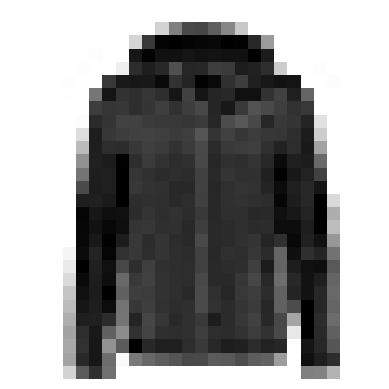

In [9]:
plt.imshow(X_train[0],cmap='binary')
plt.axis('off')
plt.show()

In [10]:
len(Y_train)

55000

In [11]:
Y_train

array([4, 0, 7, ..., 3, 0, 5], shape=(55000,), dtype=uint8)

In [12]:
class_names=["T-shirt/top","pullover","trouser","dress","coat","sandal","shirt","sneaker","bag","ankle boot"]

In [13]:
class_names[Y_train[0]]

'coat'

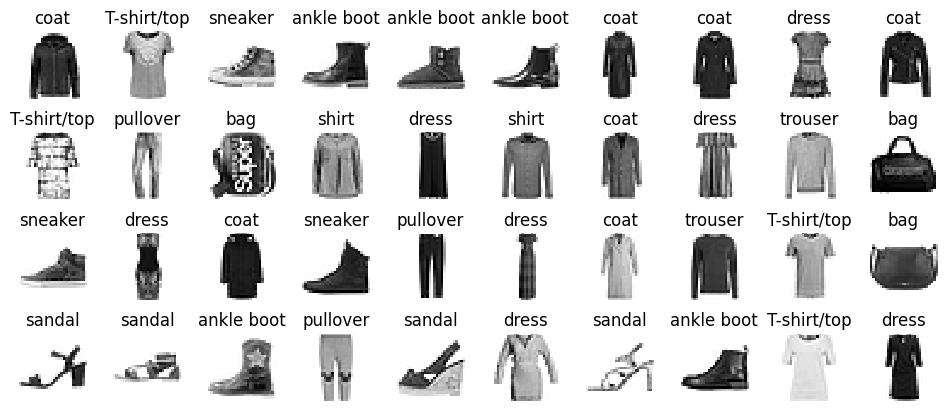

In [14]:
n_rows=4
n_cols=10
plt.figure(figsize=(n_cols*1.2,n_rows*1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index=n_cols*row+col
        plt.subplot(n_rows,n_cols,index+1)
        plt.imshow(X_train[index],cmap='binary',interpolation="nearest")
        plt.axis("off")
        plt.title(class_names[Y_train[index]],fontsize=12)
plt.subplots_adjust(wspace=0.2,hspace=0.5)
plt.show()

In [40]:
model=keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(300,activation="relu"))
model.add(keras.layers.Dense(100,activation="relu"))
model.add(keras.layers.Dense(10,activation="softmax"))


C:\Users\anuto\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [41]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [17]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.layers[0]

<Flatten name=flatten, built=True>

In [43]:
hidden1=model.layers[1]
hidden1

<Dense name=dense, built=True>

In [44]:
hidden1.name

'dense'

In [45]:
model.get_layer(hidden1.name)

<Dense name=dense, built=True>

In [46]:
model.get_layer(hidden1.name) is hidden1

True

In [50]:
weights,biases=hidden1.get_weights()
weights

array([[-0.01380094,  0.06605588, -0.03591133, ...,  0.05488193,
        -0.02345895,  0.05109662],
       [ 0.06263009,  0.05467406, -0.02182682, ..., -0.01134222,
        -0.01290473, -0.01675257],
       [-0.04691348,  0.05710725, -0.00644551, ..., -0.00718489,
         0.00685825,  0.06078276],
       ...,
       [-0.05804931,  0.06475011,  0.03164992, ...,  0.00201499,
         0.01088773,  0.01250508],
       [ 0.06071451, -0.05551973, -0.06262623, ..., -0.0317812 ,
        -0.04608009, -0.01657168],
       [-0.01621944,  0.01986716, -0.00186927, ..., -0.01621293,
         0.00851455,  0.05206783]], shape=(784, 300), dtype=float32)

In [51]:
weights.shape

(784, 300)

In [52]:
biases.shape

(300,)

In [53]:
model.compile(optimizer="sgd",
              loss="sparse_categorical_crossentropy",
              metrics=['accuracy'])

In [54]:
history=model.fit(X_train,Y_train,epochs=30,validation_data=(X_valid,Y_valid))


Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7579 - loss: 0.7321 - val_accuracy: 0.8248 - val_loss: 0.5169
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8303 - loss: 0.4882 - val_accuracy: 0.8446 - val_loss: 0.4514
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8466 - loss: 0.4422 - val_accuracy: 0.8532 - val_loss: 0.4187
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8548 - loss: 0.4146 - val_accuracy: 0.8632 - val_loss: 0.3982
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8614 - loss: 0.3946 - val_accuracy: 0.8684 - val_loss: 0.3828
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8663 - loss: 0.3783 - val_accuracy: 0.8722 - val_loss: 0.3696
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8709 - loss: 0.3649 - val_accuracy: 0.8740 - val_loss: 0.3590
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8747 - loss: 0.3529 - 

In [55]:
import pandas as pd


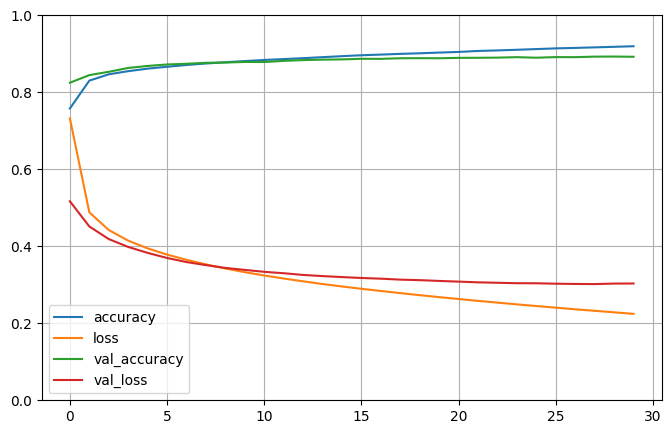

In [59]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [60]:
history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

In [61]:
history.epoch

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29]

In [62]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [63]:
print(history.history['val_accuracy'])


[0.8248000144958496, 0.8446000218391418, 0.8532000184059143, 0.8632000088691711, 0.868399977684021, 0.8722000122070312, 0.8740000128746033, 0.8766000270843506, 0.8772000074386597, 0.8787999749183655, 0.878600001335144, 0.881600022315979, 0.8835999965667725, 0.8848000168800354, 0.8853999972343445, 0.8870000243186951, 0.8867999911308289, 0.8884000182151794, 0.8885999917984009, 0.8884000182151794, 0.8894000053405762, 0.8895999789237976, 0.8899999856948853, 0.8912000060081482, 0.8898000121116638, 0.8913999795913696, 0.8912000060081482, 0.8925999999046326, 0.892799973487854, 0.8921999931335449]


In [64]:
print(history.history)


{'accuracy': [0.7579454779624939, 0.8302909135818481, 0.8466363549232483, 0.8548181653022766, 0.8614363670349121, 0.8663091063499451, 0.8709454536437988, 0.8747090697288513, 0.878036379814148, 0.8810363411903381, 0.8839272856712341, 0.8861818313598633, 0.8886181712150574, 0.8912000060081482, 0.8938000202178955, 0.8961636424064636, 0.8978727459907532, 0.8997636437416077, 0.901272714138031, 0.9031636118888855, 0.9047636389732361, 0.9073091149330139, 0.9087454676628113, 0.9104181528091431, 0.9121636152267456, 0.9140363931655884, 0.9152363538742065, 0.9166545271873474, 0.9180908799171448, 0.9196000099182129], 'loss': [0.7320593595504761, 0.4881724715232849, 0.4422176778316498, 0.4145798981189728, 0.3945659399032593, 0.3783169686794281, 0.36487579345703125, 0.35286781191825867, 0.3422026038169861, 0.33273887634277344, 0.3241370618343353, 0.3162507712841034, 0.3089050054550171, 0.3019542992115021, 0.29557523131370544, 0.28960275650024414, 0.28389713168144226, 0.2782983183860779, 0.2730072736

In [65]:
print(history)

In [66]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8794 - loss: 0.3448


[0.344805508852005, 0.8794000148773193]

In [67]:
X_new=X_test[:5]
print(model.predict(X_new))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
[[2.37395511e-06 1.18584103e-06 7.74030559e-06 3.90003879e-05
  2.90479838e-05 1.21722706e-02 1.09205694e-05 1.73602458e-02
  1.54225549e-04 9.70223069e-01]
 [5.09862584e-05 1.98105554e-09 9.96375620e-01 6.25124530e-09
  3.45064327e-03 8.34324417e-13 1.22667843e-04 9.91679070e-13
  2.90601809e-09 5.09599264e-12]
 [1.59124693e-06 9.99997735e-01 1.12973169e-08 7.29404377e-08
  5.46674073e-07 2.44810097e-12 1.22496269e-09 4.83904340e-11
  1.71410205e-10 7.35362118e-12]
 [9.57032535e-06 9.99968886e-01 5.41894394e-07 1.59218707e-05
  4.91836363e-06 6.22580920e-09 1.03281806e-07 4.85501417e-09
  1.82430793e-09 5.83445692e-09]
 [1.62132382e-01 4.58030991e-06 4.41132337e-02 8.22910632e-04
  7.30353175e-03 2.15160121e-08 7.85470724e-01 1.17393213e-07
  1.48012157e-04 4.47952289e-06]]


In [72]:
X_new=X_test[:3]
y_pred=np.argmax(model.predict(X_new),axis=1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


array([9, 2, 1])

In [73]:
np.array(class_names)[y_pred]

array(['ankle boot', 'trouser', 'pullover'], dtype='<U11')

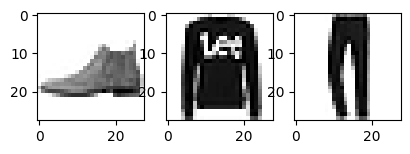

In [74]:
plt.figure(figsize=(8,5))
for row in range(1):
    for col in range(3):
        index=col
        plt.subplot(1,5,index+1)
        plt.imshow(X_test[index],cmap="binary",interpolation="nearest")
plt.subplots_adjust(wspace=0.2,hspace=0.5)
plt.show()

In [77]:
a=np.array([1,2,3])
np.array(class_names)[a]

array(['pullover', 'trouser', 'dress'], dtype='<U11')